# MLP Back-Programation

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import Callback

## 1. Avaliando Pesos Iniciais e Funções de ativação

In [22]:
# load do dataset
df = pd.read_excel("Dry_Bean_Dataset.xlsx")
x =  df.drop("Class", axis=1)
y = df["Class"]

tabela_classes = (
    df["Class"]
    .value_counts()
    .reset_index()
)

tabela_classes.columns = ["Classe", "Quantidade"]

print(tabela_classes)

# Categoria -> numero

encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Divisão do dataser

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)  

#Nomalização

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


     Classe  Quantidade
0  DERMASON        3546
1      SIRA        2636
2     SEKER        2027
3     HOROZ        1928
4      CALI        1630
5  BARBUNYA        1322
6    BOMBAY         522


In [12]:
#Rede Neural

def mlp():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(16,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(7, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [21]:
#Treinamento com pesos diferentes
seeds = [1, 2, 3, 4, 5]

historicos = []

for seed in seeds:

    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

    model = mlp()

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=32,
        verbose=0
    )

    loss_final = history.history['loss'][-1]
    acc_final = history.history['accuracy'][-1]

    historicos.append(history.history)

resultados = []

for i, h in enumerate(historicos):

    resultados.append({
        'Seed': seeds[i],
        'Loss Final': h['loss'][-1],
        'Accuracy Final': h['accuracy'][-1]
    })

df_resultados = pd.DataFrame(resultados)

print(df_resultados)

   Seed  Loss Final  Accuracy Final
0     1    0.163097        0.937821
1     2    0.161734        0.938648
2     3    0.162260        0.936719
3     4    0.160708        0.937913
4     5    0.166993        0.938464


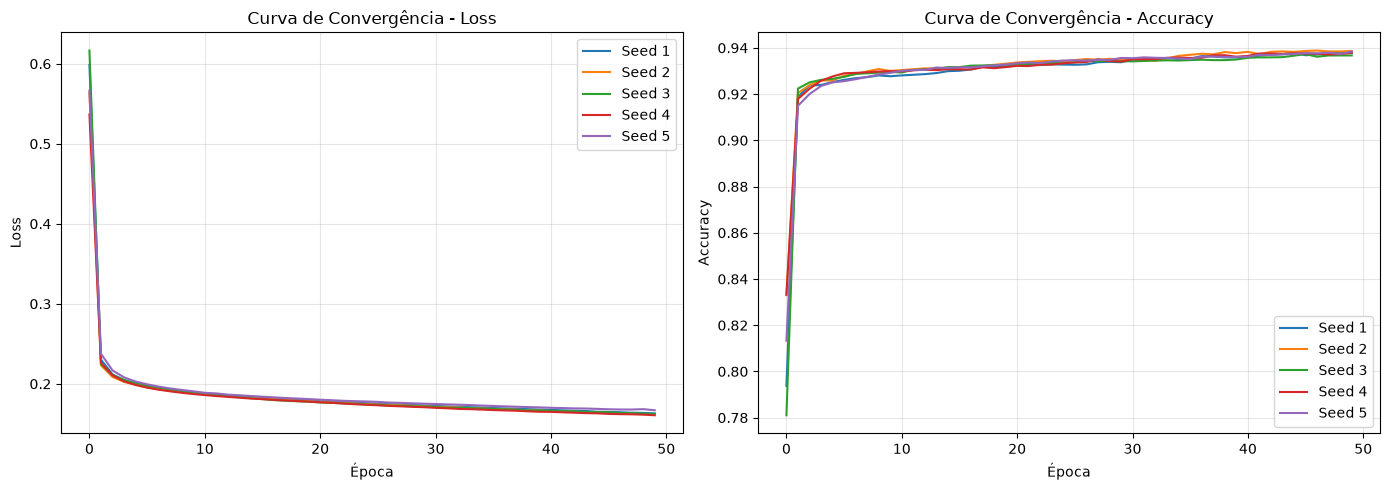

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for i, h in enumerate(historicos):
    ax1.plot(
        h['loss'],
        label=f'Seed {seeds[i]}'
    )

ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Curva de Convergência - Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
for i, h in enumerate(historicos):
    ax2.plot(
        h['accuracy'],
        label=f'Seed {seeds[i]}'
    )

ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.set_title('Curva de Convergência - Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.Taxa de Aprendizado e Termo Momento

In [25]:
class StopByLoss(Callback):

    def on_epoch_end(self, epoch, logs=None):

        if logs["loss"] <= 0.001:
            print(f"\nParando treinamento: loss = {logs['loss']:.6f}")
            self.model.stop_training = True

In [ ]:
def mlp_sgd(lr, momentum):

    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dense(7, activation='softmax')
    ])

    optimizer = SGD(
        learning_rate=lr,
        momentum=momentum
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [31]:
learning_rates = [0.001, 0.01, 0.1]
momenta = [0.5, 0.7, 0.9]

resultados = []
historicos = {}

for lr in learning_rates:

    for momentum in momenta:

        print(
            f"\nTreinando:"
            f" LR={lr}"
            f" Momentum={momentum}"
        )

        model = mlp_sgd(lr, momentum)

        history = model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=32,
            verbose=1,
            callbacks=[StopByLoss()]
        )

        historicos[(lr, momentum)] = history.history

        resultados.append({
            "Learning Rate": lr,
            "Momentum": momentum,
            "Loss Final": history.history["loss"][-1],
            "Accuracy Final": history.history["accuracy"][-1],
            "Épocas": len(history.history["loss"])
        })


Treinando: LR=0.001 Momentum=0.5
Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5365 - loss: 1.5365
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6635 - loss: 1.1604
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7142 - loss: 0.9482
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7528 - loss: 0.8095
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7908 - loss: 0.7044
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step - accuracy: 0.8282 - loss: 0.6212
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8571 - loss: 0.5553
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8749 - loss: 0.5033
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8849 - loss: 0.4623
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8921 - loss: 0.4297
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8964 - loss: 0.4033
Epoch 12/50
341/

In [32]:
df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    by="Épocas"
)

print("\nRESULTADOS:")
print(df_resultados)


RESULTADOS:
   Learning Rate  Momentum  Loss Final  Accuracy Final  Épocas
0          0.001       0.5    0.220064        0.923126      50
1          0.001       0.7    0.204364        0.926708      50
2          0.001       0.9    0.185401        0.930566      50
3          0.010       0.5    0.178795        0.932403      50
4          0.010       0.7    0.176384        0.933229      50
5          0.010       0.9    0.171244        0.937087      50
6          0.100       0.5    0.164858        0.935434      50
7          0.100       0.7    0.161329        0.937546      50
8          0.100       0.9    0.202583        0.927810      50


In [33]:
melhor = df_resultados.loc[
    df_resultados["Épocas"].idxmin()
]

print("\nMELHOR CONFIGURAÇÃO:")
print(melhor)


MELHOR CONFIGURAÇÃO:
Learning Rate      0.001000
Momentum           0.500000
Loss Final         0.220064
Accuracy Final     0.923126
Épocas            50.000000
Name: 0, dtype: float64


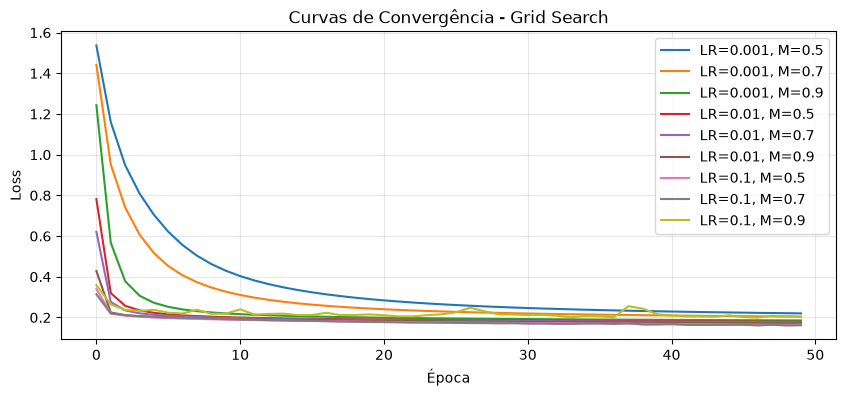

In [36]:
plt.figure(figsize=(10, 4))

for chave, hist in historicos.items():

    lr, momentum = chave

    plt.plot(
        hist["loss"],
        label=f"LR={lr}, M={momentum}"
    )

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curvas de Convergência - Grid Search")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [35]:
df_resultados["Loss Final"] = df_resultados["Loss Final"].round(4)
df_resultados["Accuracy Final"] = (
    df_resultados["Accuracy Final"] * 100
).round(2)

print("\nTABELA FINAL:")
print(df_resultados)


TABELA FINAL:
   Learning Rate  Momentum  Loss Final  Accuracy Final  Épocas
0          0.001       0.5      0.2201           92.31      50
1          0.001       0.7      0.2044           92.67      50
2          0.001       0.9      0.1854           93.06      50
3          0.010       0.5      0.1788           93.24      50
4          0.010       0.7      0.1764           93.32      50
5          0.010       0.9      0.1712           93.71      50
6          0.100       0.5      0.1649           93.54      50
7          0.100       0.7      0.1613           93.75      50
8          0.100       0.9      0.2026           92.78      50
